## Importação de bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

## Configuração visual dos gráficos

In [2]:
sns.set_theme(style="whitegrid", palette="deep")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

## Carregando e concatenando dados

In [3]:
BASE_PATH = Path("../data")
RAW_PATH = BASE_PATH / "raw"

In [4]:
train_df = pd.read_csv(RAW_PATH / "train.csv")
test_df = pd.read_csv(RAW_PATH / "test.csv")

### Concatenação dos datasets

Os conjuntos de treino e teste foram concatenados para facilitar as análises.

In [5]:
colunas_comuns = train_df.columns.intersection(test_df.columns)

In [6]:
df = pd.concat([train_df[colunas_comuns], test_df[colunas_comuns]], ignore_index=True)

## Análise Exploratória

In [7]:
df.head(10)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


### Tipos das variáveis e estatísticas descritivas

In [8]:
df.dtypes

PassengerId      int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

In [9]:
df.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,1309.000000,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000
mean,655.000000,2.294882,29.881138,0.498854,0.385027,33.295479
std,378.020061,0.837836,14.413493,1.041658,0.865560,51.758668
min,1.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,328.000000,2.000000,21.000000,0.000000,0.000000,7.895800
50%,655.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,982.000000,3.000000,39.000000,1.000000,0.000000,31.275000
max,1309.000000,3.000000,80.000000,8.000000,9.000000,512.329200


### Valores ausentes

In [10]:
df.isna().sum()

PassengerId       0
Pclass            0
Name              0
Sex               0
Age             263
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1014
Embarked          2
dtype: int64

## Qualidade e Consistência dos dados

### Investigando possíveis duplicatas

In [11]:
df.loc[df.duplicated(subset=["Ticket"])]

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
24,25,3,"Palsson, Miss. Torborg Danira",female,8.0,3,1,349909,21.0750,NaN,S
71,72,3,"Goodwin, Miss. Lillian Amy",female,16.0,5,2,CA 2144,46.9000,NaN,S
88,89,1,"Fortune, Miss. Mabel Helen",female,23.0,3,2,19950,263.0000,C23 C25 C27,S
117,118,2,"Turpin, Mr. William John Robert",male,29.0,1,0,11668,21.0000,NaN,S
119,120,3,"Andersson, Miss. Ellis Anna Maria",female,2.0,4,2,347082,31.2750,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
1298,1299,1,"Widener, Mr. George Dunton",male,50.0,1,1,113503,211.5000,C80,C
1300,1301,3,"Peacock, Miss. Treasteall",female,3.0,1,1,SOTON/O.Q. 3101315,13.7750,NaN,S
1302,1303,1,"Minahan, Mrs. William Edward (Lillian E Thorpe)",female,37.0,1,0,19928,90.0000,C78,Q
1305,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C


Foi realizada uma investigação de tickets repetidos, pois múltiplos passageiros podem compartilhar o mesmo ticket devido a viagens em grupo ou familiares.

### Cardinalidade das variáveis


In [12]:
df.nunique()

PassengerId    1309
Pclass            3
Name           1307
Sex               2
Age              98
SibSp             7
Parch             8
Ticket          929
Fare            281
Cabin           186
Embarked          3
dtype: int64

## Análise Univariada

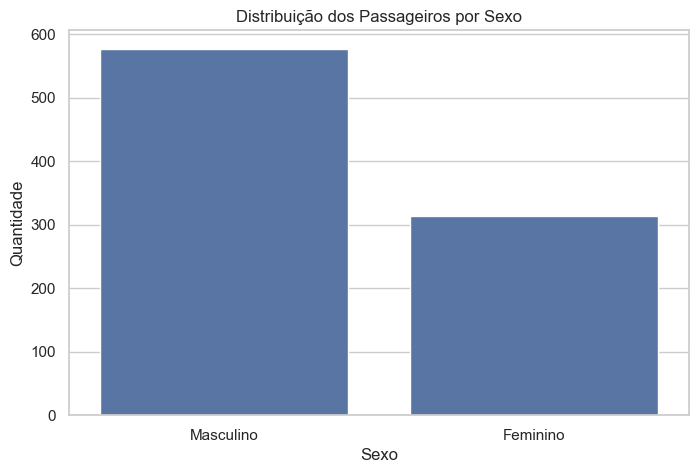

In [31]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=train_df.assign(
        Sex=train_df["Sex"].map({
            "male": "Masculino",
            "female": "Feminino"
        })
    ),
    x="Sex"
)

plt.title("Distribuição dos Passageiros por Sexo")
plt.xlabel("Sexo")
plt.ylabel("Quantidade")

plt.show()

In [26]:
survival_by_sex = train_df.groupby("Sex")["Survived"].mean()
print(survival_by_sex)

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


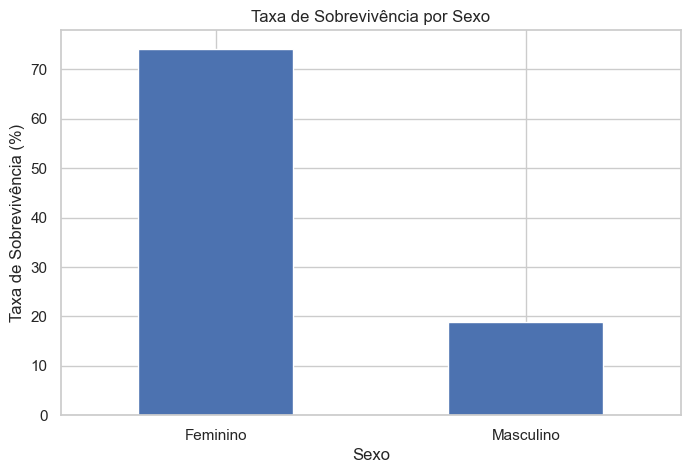

In [33]:
survival_by_sex = (
    train_df.groupby("Sex")["Survived"]
    .mean()
    .mul(100)
)

survival_by_sex.index = survival_by_sex.index.map({
    "male": "Masculino",
    "female": "Feminino"
})

plt.figure(figsize=(8, 5))

survival_by_sex.plot(
    kind="bar",
)

plt.title("Taxa de Sobrevivência por Sexo")
plt.xlabel("Sexo")
plt.ylabel("Taxa de Sobrevivência (%)")
plt.xticks(rotation=0)

plt.show()

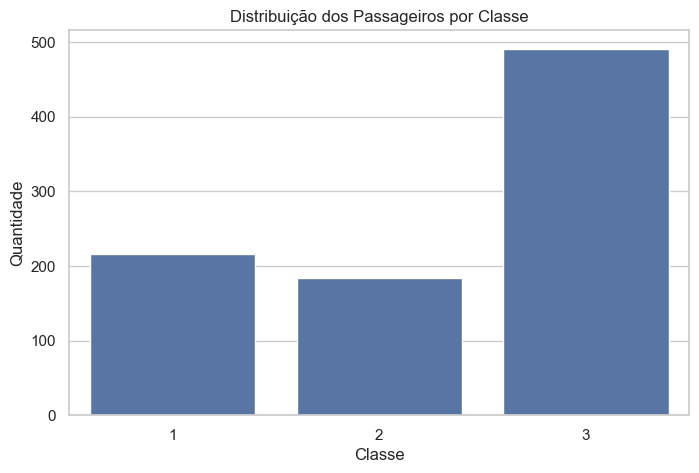

In [42]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=train_df,
    x="Pclass",
    order=[1, 2, 3]
)

plt.title("Distribuição dos Passageiros por Classe")
plt.xlabel("Classe")
plt.ylabel("Quantidade")

plt.show()

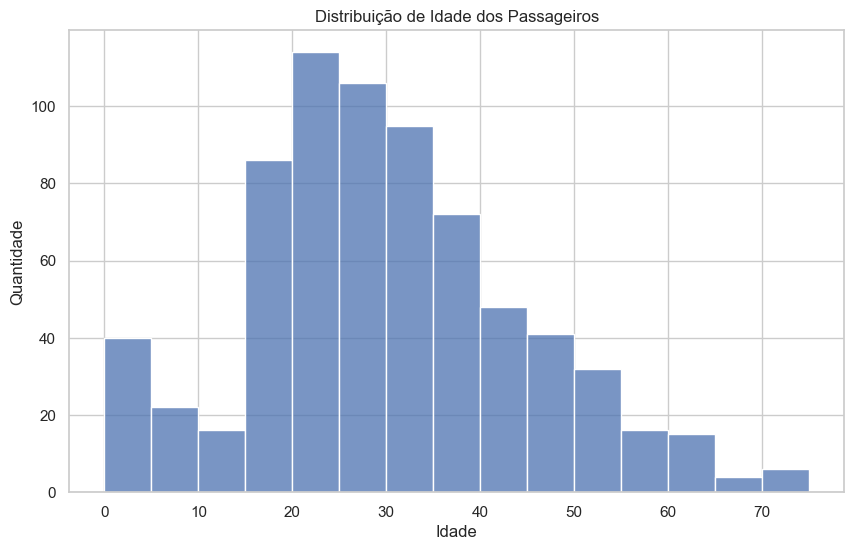

In [17]:
plt.figure(figsize=(10, 6))

sns.histplot(
    train_df["Age"],
    bins=np.arange(0, 80, 5),
)

plt.title("Distribuição de Idade dos Passageiros")
plt.xlabel("Idade")
plt.ylabel("Quantidade")
plt.show()

<Axes: xlabel='AgeGroup'>

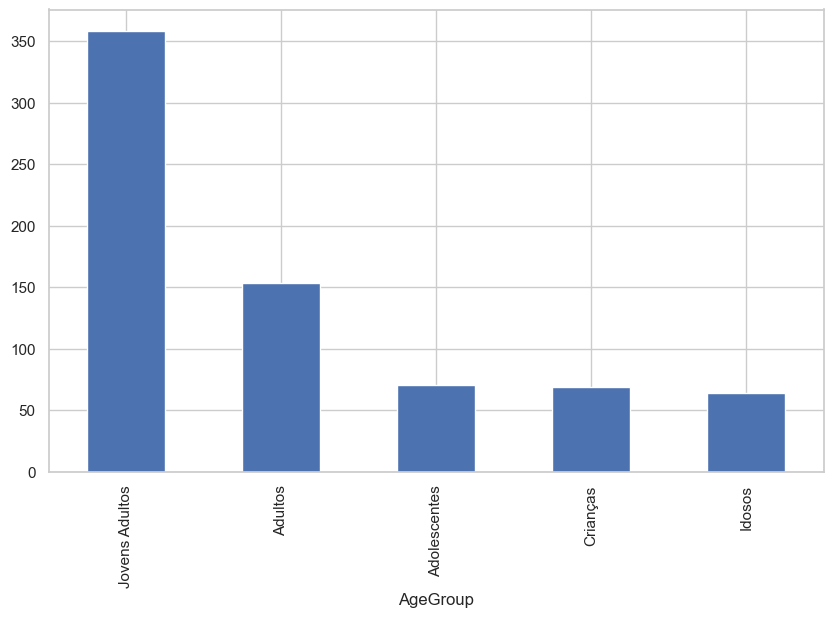

In [47]:
train_df["AgeGroup"] = pd.cut(
    train_df["Age"],
    bins=[0, 12, 18, 35, 50, 100],
    labels=["Crianças","Adolescentes","Jovens Adultos","Adultos","Idosos"]
)

train_df["AgeGroup"].value_counts().plot(kind="bar")

## Análise Multivariada

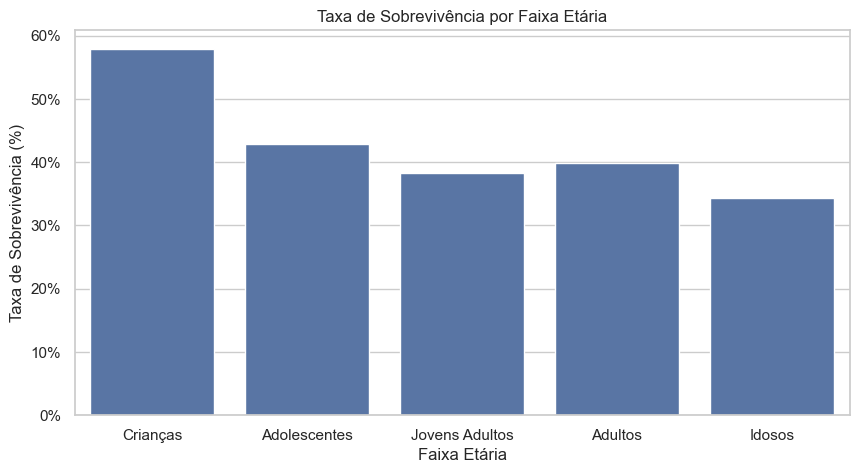

In [48]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=train_df,
    x="AgeGroup",
    y="Survived",
    errorbar=None
)

plt.title("Taxa de Sobrevivência por Faixa Etária")
plt.xlabel("Faixa Etária")
plt.ylabel("Taxa de Sobrevivência (%)")

plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"{y*100:.0f}%")
)

plt.show()

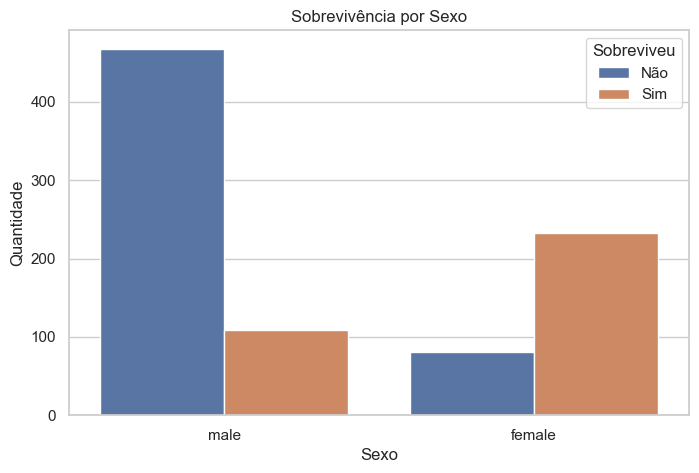

In [18]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=train_df,
    x="Sex",
    hue="Survived"
)

plt.title("Sobrevivência por Sexo")
plt.xlabel("Sexo")
plt.ylabel("Quantidade")
plt.legend(title="Sobreviveu", labels=["Não", "Sim"])

plt.show()

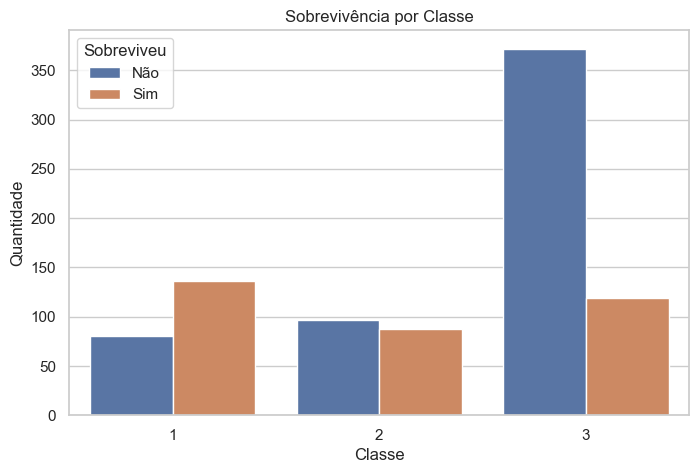

In [19]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=train_df,
    x="Pclass",
    hue="Survived"
)

plt.title("Sobrevivência por Classe")
plt.xlabel("Classe")
plt.ylabel("Quantidade")
plt.legend(title="Sobreviveu", labels=["Não", "Sim"])

plt.show()

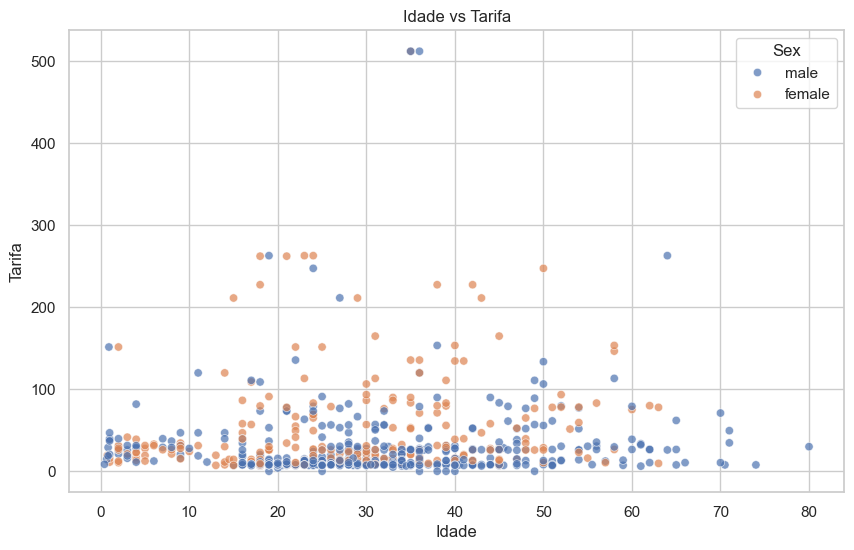

In [46]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=train_df,
    x="Age",
    y="Fare",
    hue="Sex",
    alpha=0.7
)

plt.title("Idade vs Tarifa")
plt.xlabel("Idade")
plt.ylabel("Tarifa")
plt.show()

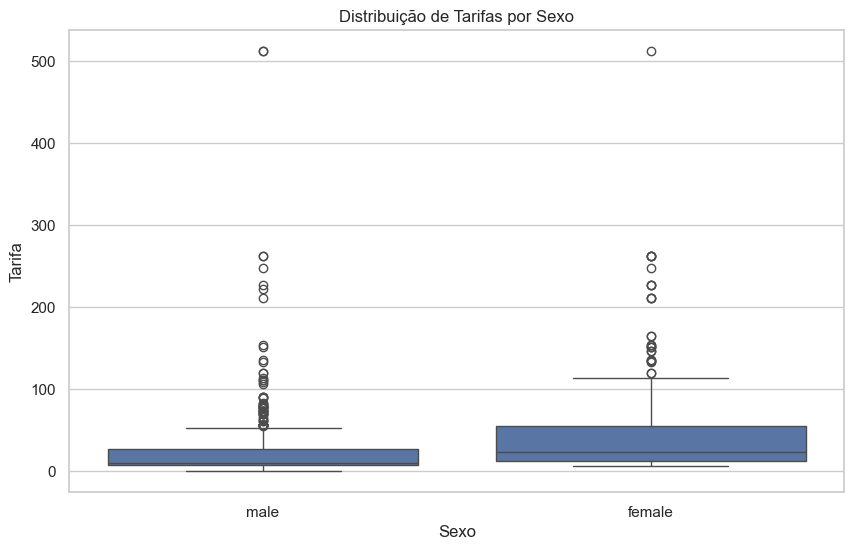

In [21]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=train_df,
    x="Sex",
    y="Fare"
)

plt.title("Distribuição de Tarifas por Sexo")
plt.xlabel("Sexo")
plt.ylabel("Tarifa")

plt.show()

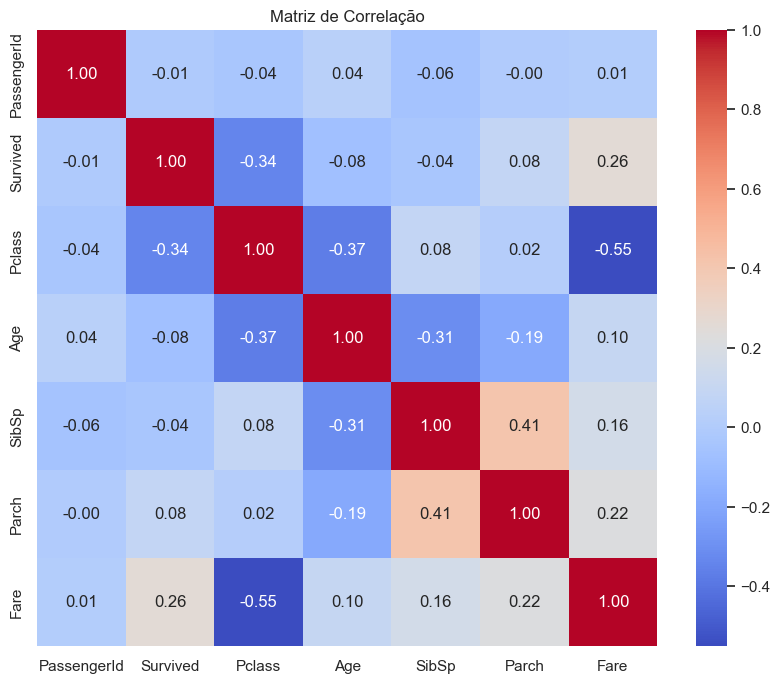

In [22]:
corr = train_df.select_dtypes(include=["number"]).corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matriz de Correlação")
plt.show()

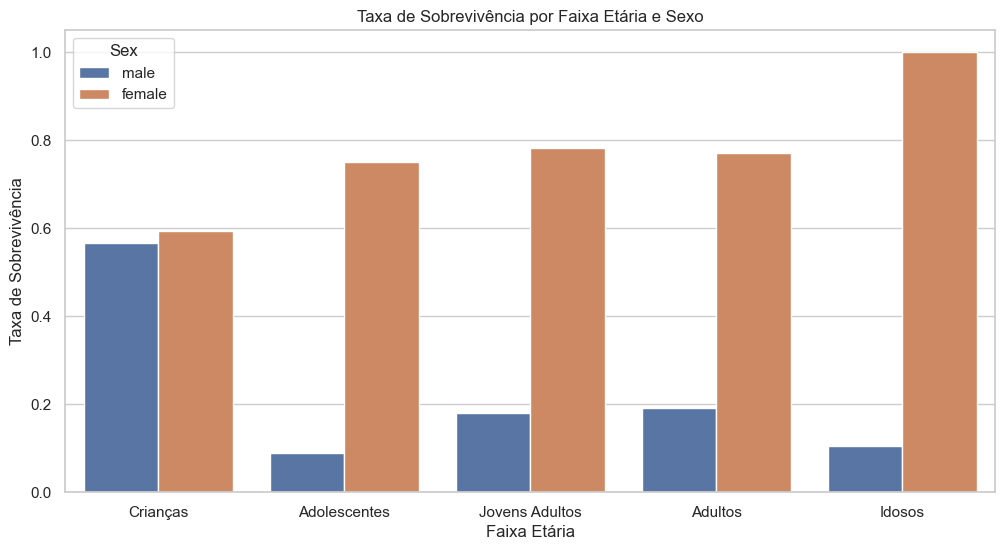

In [25]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=train_df,
    x="AgeGroup",
    y="Survived",
    hue="Sex",
    errorbar=None
)

plt.title("Taxa de Sobrevivência por Faixa Etária e Sexo")
plt.xlabel("Faixa Etária")
plt.ylabel("Taxa de Sobrevivência")

plt.show()